#  New Year Sales Analysis using Python

## Project Overview

This project focuses on analyzing New Year sales data to identify customer purchasing patterns, demographic trends, and business insights using Python.

The analysis includes data cleaning, exploratory data analysis (EDA), and visualization techniques to understand how different customer attributes such as gender, age group, state, marital status, occupation, and product category influence purchasing behavior.

## Objectives

- Import and explore the sales dataset.
- Perform data cleaning and preprocessing.
- Analyze customer demographics.
- Identify top-performing states and product categories.
- Understand purchasing behavior based on different customer segments.
- Generate meaningful business insights from the data.

## Tools & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [13]:
#Step 1 Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [14]:
%matplotlib inline

In [4]:
# Step 2 Load and Explore the Dataset

df = pd.read_csv("New Year Sales Data.csv", encoding='unicode_escape')

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,Female,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,Female,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,Female,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,Male,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,Male,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [7]:
df.tail()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
11246,1000695,Manning,P00296942,Male,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,Male,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,Female,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,Male,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN
11250,1002744,Brumley,P00281742,Female,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.0,NaN,NaN


In [8]:
df.shape

(11251, 15)

In [10]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [12]:
df.sample(5, random_state=42)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
5749,1006036,Halladay,P00115242,Male,26-35,30,0,Haryana,Northern,Banking,Electronics & Gadgets,4,8072.0,NaN,NaN
7335,1003110,Sara,P00288942,Female,26-35,31,0,Uttar Pradesh,Central,Retail,Clothing & Apparel,2,6981.0,NaN,NaN
5932,1002167,Gannaway,P00187342,Male,26-35,28,1,Uttarakhand,Central,Automobile,Electronics & Gadgets,3,8008.0,NaN,NaN
3819,1002083,Mohan,P00216342,Female,18-25,22,0,Karnataka,Southern,Chemical,Food,2,11378.0,NaN,NaN
6395,1003387,Amol,P00216842,Female,18-25,22,0,Rajasthan,Northern,Food Processing,Electronics & Gadgets,4,7843.0,NaN,NaN


In [15]:
# Step 3 Data Cleaning

df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [16]:
(df.isnull().sum() / len(df)) * 100

User_ID               0.000000
Cust_name             0.000000
Product_ID            0.000000
Gender                0.000000
Age Group             0.000000
Age                   0.000000
Marital_Status        0.000000
State                 0.000000
Zone                  0.000000
Occupation            0.000000
Product_Category      0.000000
Orders                0.000000
Amount                0.106657
Status              100.000000
unnamed1            100.000000
dtype: float64

In [17]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [18]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [19]:
df.dropna(inplace=True)

In [20]:
df.shape

(11239, 13)

In [25]:
df['Amount'].dtype
# As befor when we did info we got to know the dtype as well as written in instruction

dtype('float64')

In [26]:
df['Amount'] = df['Amount'].astype('int')

In [27]:
df['Amount'].dtype

dtype('int64')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11239 non-null  int64 
 1   Cust_name         11239 non-null  object
 2   Product_ID        11239 non-null  object
 3   Gender            11239 non-null  object
 4   Age Group         11239 non-null  object
 5   Age               11239 non-null  int64 
 6   Marital_Status    11239 non-null  int64 
 7   State             11239 non-null  object
 8   Zone              11239 non-null  object
 9   Occupation        11239 non-null  object
 10  Product_Category  11239 non-null  object
 11  Orders            11239 non-null  int64 
 12  Amount            11239 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 1.2+ MB


In [30]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

## Data Cleaning Summary

The dataset was successfully cleaned by performing the following operations:

- Checked for missing values in all columns.
- Removed the `Status` and `unnamed1` columns as they contained no useful information.
- Deleted rows with missing values to ensure data quality.
- Converted the `Amount` column from float to integer for consistent calculations.
- Verified the cleaned dataset using `info()` and a final missing value check.

The dataset is now clean and ready for exploratory data analysis (EDA).

In [31]:
# Step 4 Data Overview and Summary 

df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [32]:
df.describe(include='object')

,Cust_name,Product_ID,Gender,Age Group,State,Zone,Occupation,Product_Category
count,11239,11239,11239,11239,11239,11239,11239,11239
unique,1250,2350,2,7,16,5,15,18
top,Vishakha,P00265242,Female,26-35,Uttar Pradesh,Central,IT Sector,Clothing & Apparel
freq,42,53,7832,4541,1944,4289,1583,2655


In [33]:
df.nunique()

User_ID             3752
Cust_name           1250
Product_ID          2350
Gender                 2
Age Group              7
Age                   81
Marital_Status         2
State                 16
Zone                   5
Occupation            15
Product_Category      18
Orders                 4
Amount              6583
dtype: int64

In [34]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [35]:
df['Age Group'].unique()

array(['26-35', '0-17', '18-25', '51-55', '46-50', '55+', '36-45'],
      dtype=object)

In [36]:
df['State'].unique()

array(['Maharashtra', 'Andhra\xa0Pradesh', 'Uttar Pradesh', 'Karnataka',
       'Gujarat', 'Himachal Pradesh', 'Delhi', 'Jharkhand', 'Kerala',
       'Haryana', 'Madhya Pradesh', 'Bihar', 'Rajasthan', 'Uttarakhand',
       'Telangana', 'Punjab'], dtype=object)

In [37]:
df['Occupation'].unique()

array(['Healthcare', 'Govt', 'Automobile', 'Construction',
       'Food Processing', 'Lawyer', 'Media', 'Banking', 'Retail',
       'IT Sector', 'Aviation', 'Hospitality', 'Agriculture', 'Textile',
       'Chemical'], dtype=object)

In [38]:
df['Product_Category'].unique()

array(['Auto', 'Hand & Power Tools', 'Stationery', 'Tupperware',
       'Footwear & Shoes', 'Furniture', 'Food', 'Games & Toys',
       'Sports Products', 'Books', 'Electronics & Gadgets', 'Decor',
       'Clothing & Apparel', 'Beauty', 'Household items', 'Pet Care',
       'Veterinary', 'Office'], dtype=object)

In [39]:
df['Gender'].value_counts()

Gender
Female    7832
Male      3407
Name: count, dtype: int64

In [40]:
df['Product_Category'].value_counts()

Product_Category
Clothing & Apparel       2655
Food                     2490
Electronics & Gadgets    2087
Footwear & Shoes         1059
Household items           520
Beauty                    422
Games & Toys              386
Sports Products           356
Furniture                 352
Pet Care                  212
Office                    113
Stationery                112
Books                     103
Auto                       97
Decor                      96
Veterinary                 81
Tupperware                 72
Hand & Power Tools         26
Name: count, dtype: int64

## Data Overview Summary

The dataset overview provided a clear understanding of both numerical and categorical variables.

Key observations:
- Summary statistics helped identify the range and distribution of numerical features such as Age, Orders, and Amount.
- Categorical summaries highlighted the most common values in columns like Gender, Occupation, and Product Category.
- The dataset contains multiple customer segments across different states, occupations, and product categories, making it suitable for detailed exploratory data analysis.

The dataset is now fully understood and ready for visualization and business insight generation.

## Exploratory Data Analysis (EDA)

## 1. Gender Analysis

### Business Question

**Which gender has a higher purchasing power?**

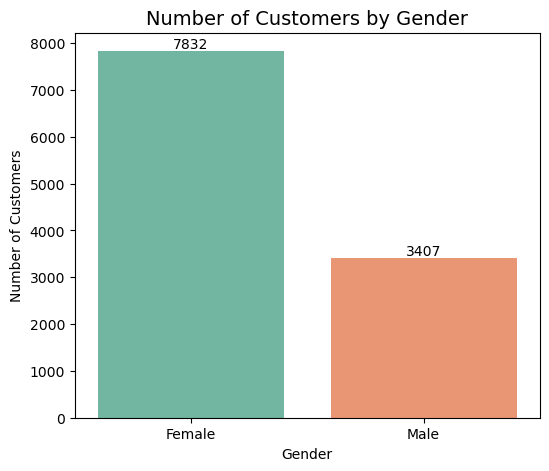

In [42]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='Gender',
    palette='Set2'
)

# Display count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Customers by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

### Observation

- The count plot shows the distribution of customers by gender.
- Female customers represent a larger proportion of the customer base compared to male customers.
- This indicates that female customers made more purchases during the New Year sales period.

In [43]:
sales_by_gender = df.groupby('Gender', as_index=False)['Amount'].sum()

sales_by_gender

,Gender,Amount
0,Female,74335853
1,Male,31913276


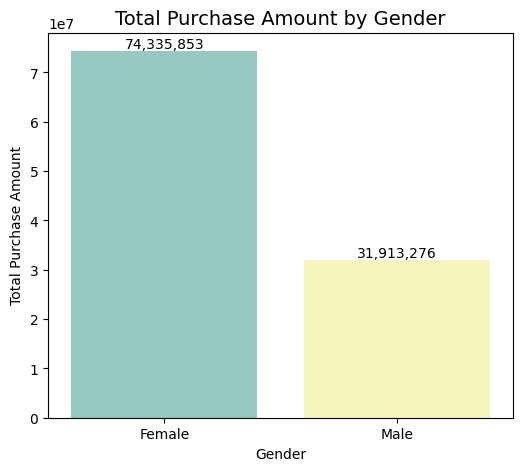

In [48]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=sales_by_gender,
    x='Gender',
    y='Amount',
    palette='Set3'
)

# Add value labels with commas (e.g., 74,335,853)
for container in ax.containers:
    labels = [f'{val:,.0f}' for val in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.title('Total Purchase Amount by Gender', fontsize=14)

plt.xlabel('Gender')

plt.ylabel('Total Purchase Amount')

plt.show()

### Observation

- Female customers contribute a significantly higher total purchase amount than male customers.
- This indicates that female customers not only make more purchases but also contribute more to the overall sales revenue.

## 2. Age Group Analysis

### Business Question

**Which age group has the highest number of purchases, and how does purchasing power vary across different age groups?**

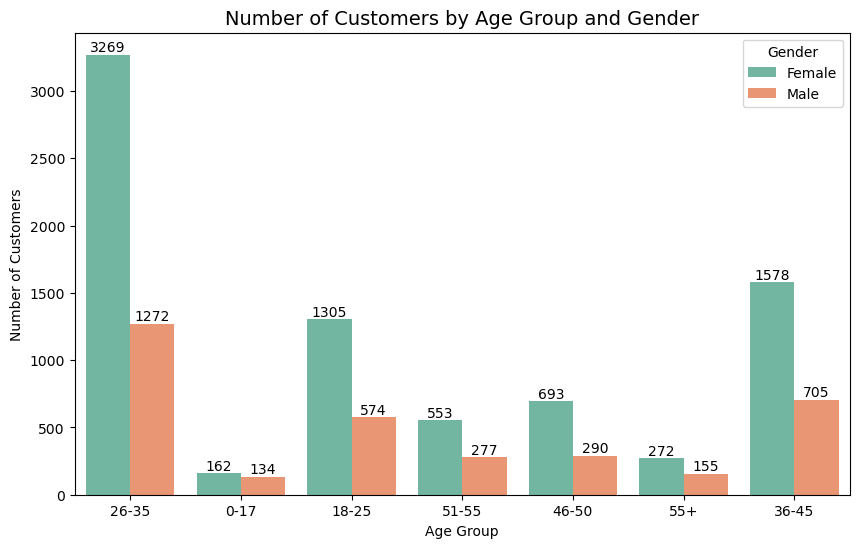

In [49]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x='Age Group',
    hue='Gender',
    palette='Set2'
)

# Display count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Customers by Age Group and Gender', fontsize=14)

plt.xlabel('Age Group')

plt.ylabel('Number of Customers')

plt.legend(title='Gender')

plt.show()

### Observation

- The customer distribution varies across different age groups.
- The **26–35** age group has the highest number of purchases.
- Female customers dominate most age groups, particularly between **26–35 years**, indicating stronger participation in shopping during the sales period.

In [61]:
sales_by_age = df.groupby(
    'Age Group',
    as_index=False
)['Amount'].sum().sort_values(
    by='Amount',
    ascending=False
)
sales_by_age

,Age Group,Amount
2,26-35,42613442
3,36-45,22144994
1,18-25,17240732
4,46-50,9207844
5,51-55,8261477
6,55+,4080987
0,0-17,2699653


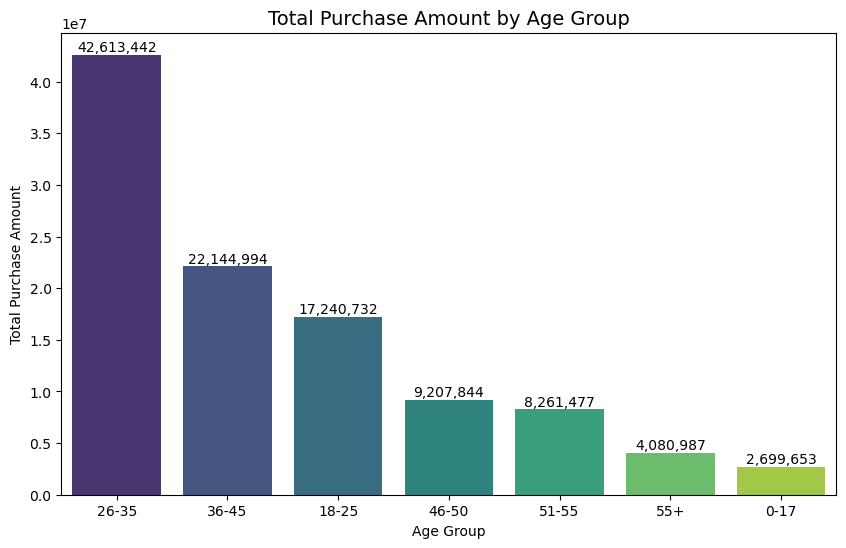

In [62]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=sales_by_age,
    x='Age Group',
    y='Amount',
    palette='viridis'
)

# Display value labels
for container in ax.containers:
    labels = [f'{val:,.0f}' for val in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.title('Total Purchase Amount by Age Group', fontsize=14)

plt.xlabel('Age Group')

plt.ylabel('Total Purchase Amount')

plt.show()

### Observation

- The **26–35 years** age group contributes the highest purchase amount.
- The purchasing power gradually decreases for higher age groups.
- Female customers are the major contributors within the high-spending age groups.

## 3. State Analysis

### Business Question

**Which states generate the highest number of orders and the highest sales revenue?**

In [58]:
orders_by_state = (
    df.groupby('State', as_index=False)['Orders']
      .sum()
      .sort_values(by='Orders', ascending=False)
      .head(10)
)

orders_by_state

,State,Orders
14,Uttar Pradesh,4807
10,Maharashtra,3810
7,Karnataka,3240
2,Delhi,2740
9,Madhya Pradesh,2252
0,Andhra Pradesh,2051
5,Himachal Pradesh,1568
8,Kerala,1137
4,Haryana,1109
3,Gujarat,1066


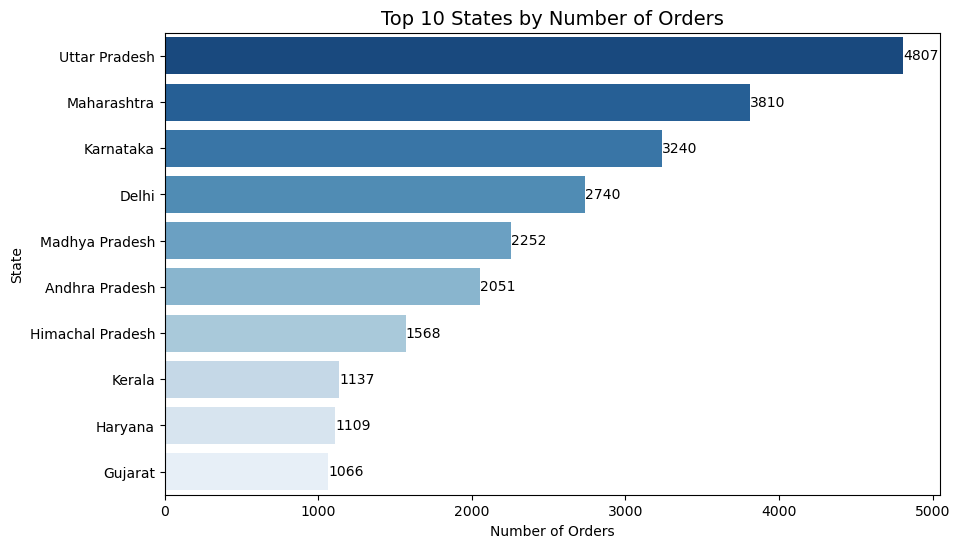

In [59]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=orders_by_state,
    y='State',
    x='Orders',
    palette='Blues_r'
)

# Display value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Top 10 States by Number of Orders', fontsize=14)

plt.xlabel('Number of Orders')

plt.ylabel('State')

plt.show()

### Observation

- The chart shows the top 10 states based on the total number of orders.
- States such as **Uttar Pradesh, Maharashtra, and Karnataka** are among the leading contributors in terms of order volume.
- These states have a larger customer base and higher purchasing activity during the sales period.

In [63]:
sales_by_state = (
    df.groupby('State', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
      .head(10)
)

sales_by_state

,State,Amount
14,Uttar Pradesh,19374968
10,Maharashtra,14427543
7,Karnataka,13523540
2,Delhi,11603818
9,Madhya Pradesh,8101142
0,Andhra Pradesh,8037146
5,Himachal Pradesh,4963368
4,Haryana,4220175
1,Bihar,4022757
3,Gujarat,3946082


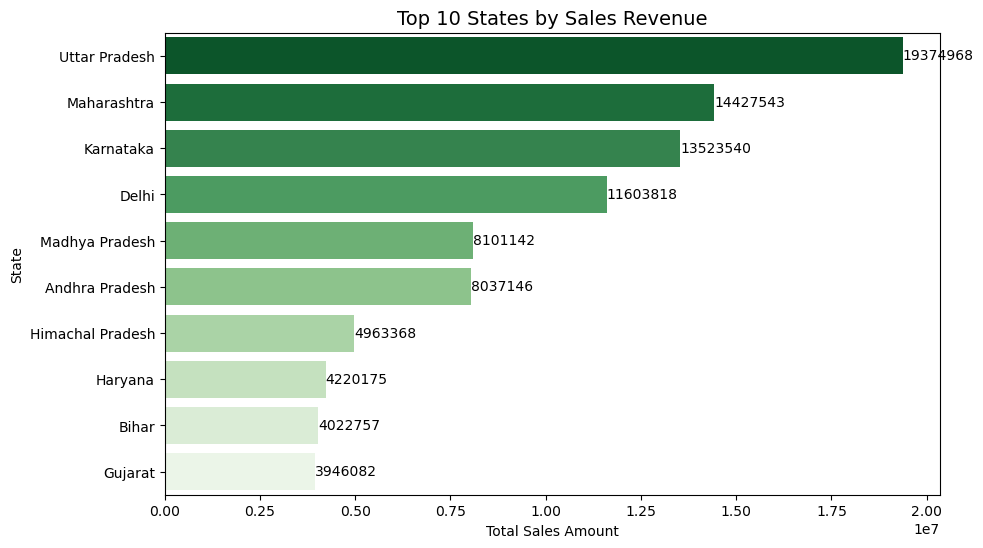

In [64]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=sales_by_state,
    y='State',
    x='Amount',
    palette='Greens_r'
)

# Display value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Top 10 States by Sales Revenue', fontsize=14)

plt.xlabel('Total Sales Amount')

plt.ylabel('State')

plt.show()

### Observation

- The top 10 states contribute the largest share of total sales revenue.
- States such as **Uttar Pradesh, Maharashtra, and Karnataka** generate the highest sales amount.
- These states exhibit strong purchasing power and play a significant role in overall business revenue.

## 4. Marital Status Analysis

### Business Question

**How does marital status influence customer purchasing behavior?**

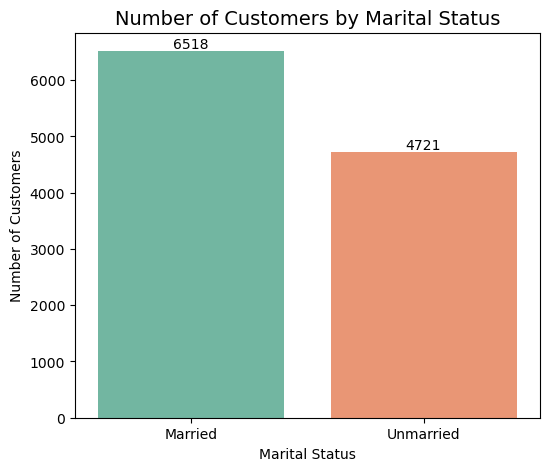

In [65]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='Marital_Status',
    palette='Set2'
)

# Display count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Customers by Marital Status', fontsize=14)

plt.xlabel('Marital Status')

plt.ylabel('Number of Customers')

# Rename x-axis tick labels
plt.xticks(ticks=[0,1], labels=['Married', 'Unmarried'])

plt.show()

### Observation

- The chart displays the distribution of customers based on marital status.
- Married customers represent a larger share of the customer base compared to unmarried customers.
- This indicates higher participation from married customers during the New Year sales period.

In [66]:
sales_by_marital = (
    df.groupby(
        ['Marital_Status', 'Gender'],
        as_index=False
    )['Amount']
    .sum()
)

sales_by_marital

,Marital_Status,Gender,Amount
0,0,Female,43786646
1,0,Male,18338738
2,1,Female,30549207
3,1,Male,13574538


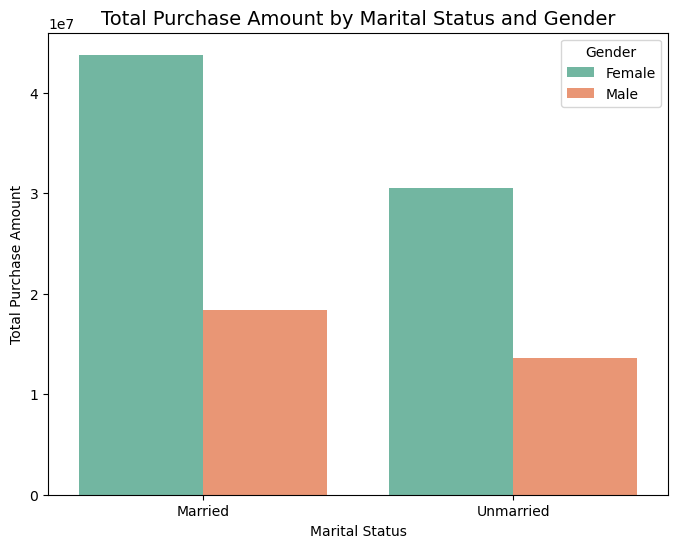

In [67]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=sales_by_marital,
    x='Marital_Status',
    y='Amount',
    hue='Gender',
    palette='Set2'
)

# Rename x-axis labels
plt.xticks(ticks=[0,1], labels=['Married', 'Unmarried'])

plt.title('Total Purchase Amount by Marital Status and Gender', fontsize=14)

plt.xlabel('Marital Status')

plt.ylabel('Total Purchase Amount')

plt.legend(title='Gender')

plt.show()

### Observation

- Married customers contribute a larger share of the total purchase amount.
- Among married customers, female customers generate the highest sales revenue.
- This indicates that married women are one of the strongest customer segments in the dataset.

## 5. Occupation Analysis

### Business Question

**Which occupations contribute the most to sales?**

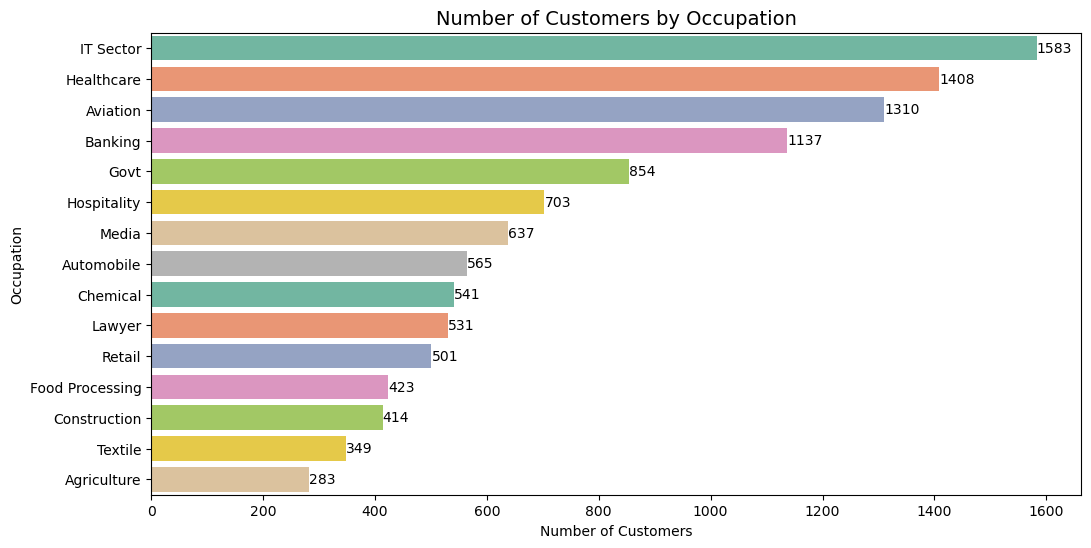

In [68]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    y='Occupation',
    order=df['Occupation'].value_counts().index,
    palette='Set2'
)

# Display count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Customers by Occupation', fontsize=14)

plt.xlabel('Number of Customers')

plt.ylabel('Occupation')

plt.show()

### Observation

- The chart shows the distribution of customers across different occupations.
- Occupations such as **IT Sector, Healthcare, and Aviation** have a higher number of customers compared to other occupations.
- This indicates that these professions contribute significantly to customer participation during the sales period.

In [70]:
sales_by_occupation = (
    df.groupby('Occupation', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

sales_by_occupation

,Occupation,Amount
10,IT Sector,14755079
8,Healthcare,13034586
2,Aviation,12602298
3,Banking,10770610
7,Govt,8517212
9,Hospitality,6376405
12,Media,6295832
1,Automobile,5368596
4,Chemical,5297436
11,Lawyer,4981665


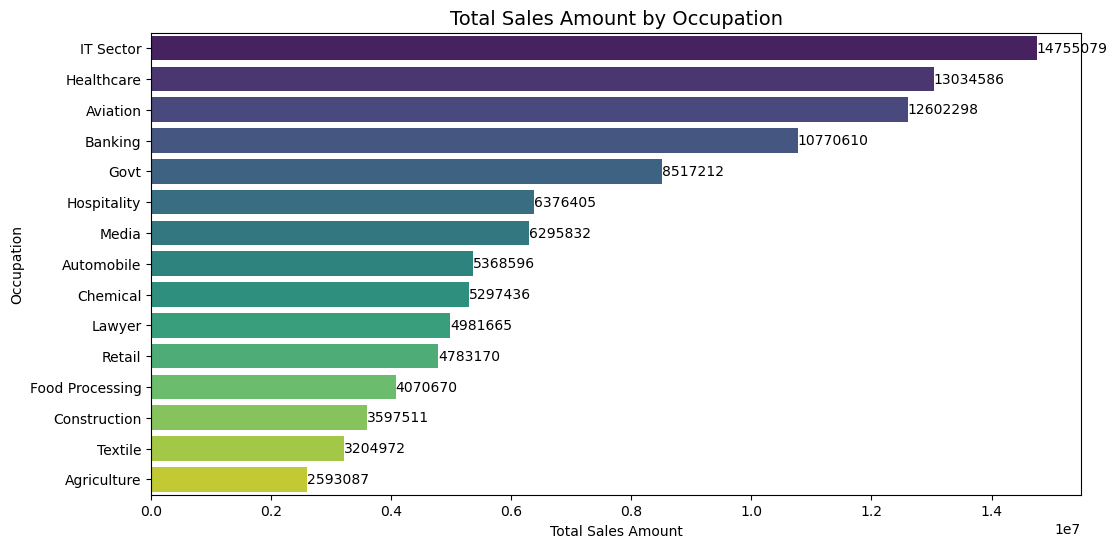

In [71]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=sales_by_occupation,
    y='Occupation',
    x='Amount',
    palette='viridis'
)

# Display value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Total Sales Amount by Occupation', fontsize=14)

plt.xlabel('Total Sales Amount')

plt.ylabel('Occupation')

plt.show()

### Observation

- Customers working in **IT Sector, Healthcare, and Aviation** contribute the highest sales revenue.
- These occupations demonstrate stronger purchasing power compared to other occupational groups.
- Higher income levels in these professions may contribute to increased spending during the sales period.

## 6. Product Category Analysis

### Business Question

**Which product categories are the most popular, and which categories generate the highest sales revenue?**


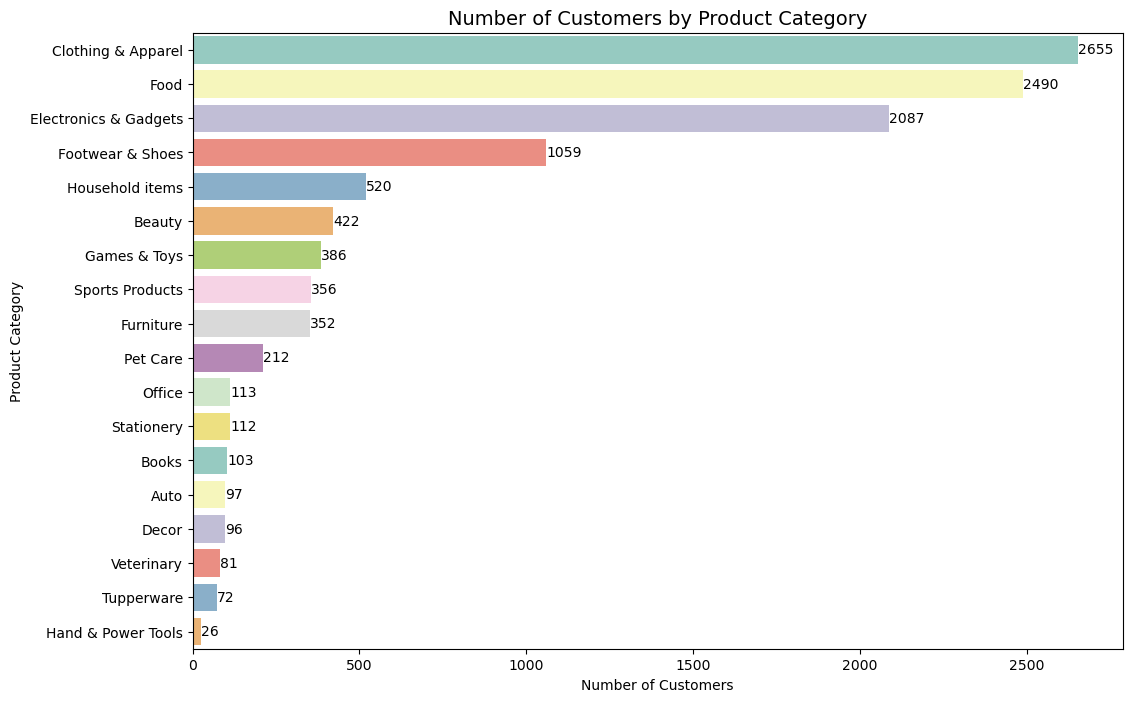

In [73]:
plt.figure(figsize=(12,8))

ax = sns.countplot(
    data=df,
    y='Product_Category',
    order=df['Product_Category'].value_counts().index,
    palette='Set3'
)

# Display count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Customers by Product Category', fontsize=14)

plt.xlabel('Number of Customers')

plt.ylabel('Product Category')

plt.show()

### Observation

- The chart shows the distribution of purchases across different product categories.
- Categories such as **Clothing & Apparel, Food, and Electronics & Gadgets** receive the highest number of purchases.
- These categories are the most popular among customers during the sales period.

In [74]:
sales_by_category = (
    df.groupby('Product_Category', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

sales_by_category

,Product_Category,Amount
6,Food,33933883
3,Clothing & Apparel,16495019
5,Electronics & Gadgets,15643846
7,Footwear & Shoes,15575209
8,Furniture,5440051
9,Games & Toys,4331694
14,Sports Products,3635933
1,Beauty,1959484
0,Auto,1958609
15,Stationery,1676051


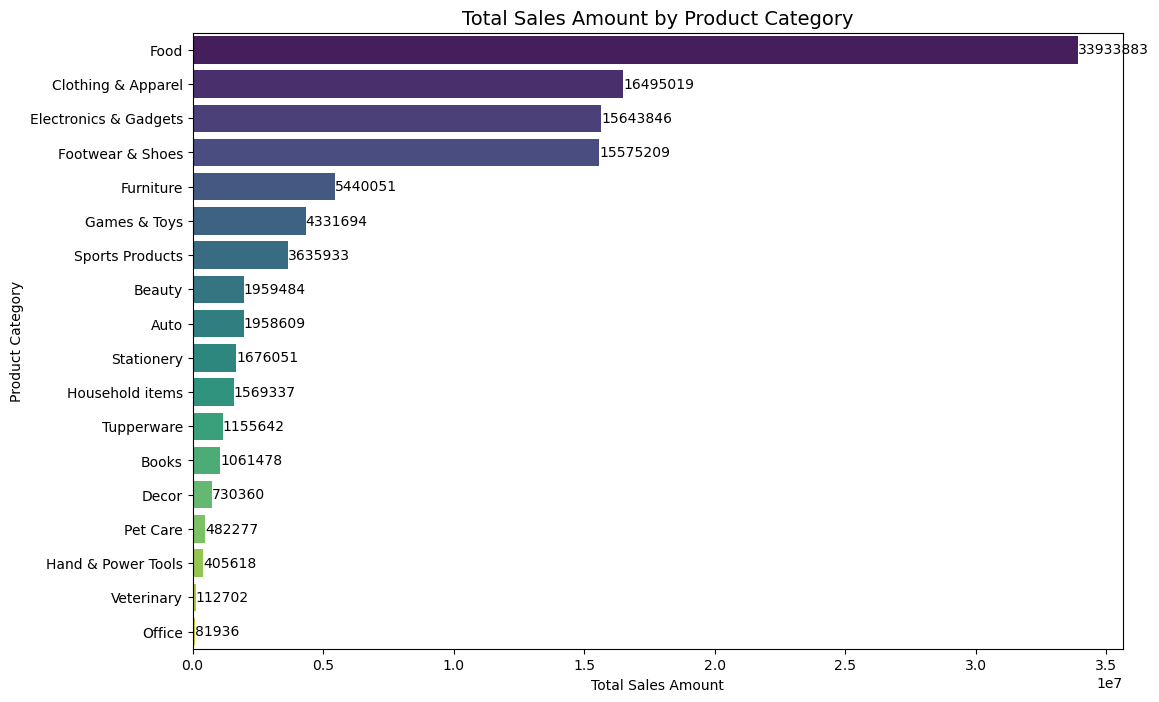

In [75]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=sales_by_category,
    y='Product_Category',
    x='Amount',
    palette='viridis'
)

# Display value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Total Sales Amount by Product Category', fontsize=14)

plt.xlabel('Total Sales Amount')

plt.ylabel('Product Category')

plt.show()

### Observation

- The highest revenue is generated by a few key product categories.
- Categories such as **Food, Clothing & Apparel, and Electronics & Gadgets** contribute significantly to the overall sales revenue.
- These categories demonstrate strong customer demand and purchasing power.

# Conclusion

The analysis of the New Year Sales dataset provided valuable insights into customer purchasing behavior across different demographic and product-related factors. The exploratory data analysis helped identify the major customer segments, high-performing regions, and product categories contributing to overall sales.

Based on the analysis, the following key findings and business insights were observed.

## Key Findings

- Female customers contributed a higher number of purchases and generated greater overall sales revenue than male customers.
- Customers belonging to the **26–35 years** age group represented the most active and highest-spending customer segment.
- The top-performing states generated a significant share of total orders and revenue, indicating strong regional demand.
- Married customers, particularly married women, showed higher purchasing power compared to other customer groups.
- Customers working in occupations such as **IT Sector, Healthcare, and Aviation** contributed substantially to total sales.
- A few major product categories accounted for the majority of purchases and revenue, making them the primary drivers of business performance.

## High-Purchasing Customer Profile

Based on the analysis, the typical high-purchasing customer can be described as:

- Gender: Female
- Age Group: 26–35 years
- Marital Status: Married
- Occupation: IT Sector / Healthcare / Aviation (based on the analysis)
- Location: One of the top-performing states identified in the analysis
- Purchasing Behavior: Frequently purchases products from the highest-performing product categories and contributes significantly to the overall sales revenue.

## Additional Questions

## 1. Which age group contributes the most to each product category, and does this vary by gender?

### Business Question

Which age groups contribute the most to different product categories, and how do purchasing patterns differ between male and female customers?

In [84]:
age_product = (
    df.groupby(['Age Group', 'Product_Category'])['Amount']
      .sum()
      .unstack(fill_value=0)
)

age_product

Product_Category,Auto,Beauty,Books,Clothing & Apparel,Decor,Electronics & Gadgets,Food,Footwear & Shoes,Furniture,Games & Toys,Hand & Power Tools,Household items,Office,Pet Care,Sports Products,Stationery,Tupperware,Veterinary
Age Group,,,,,,,,,,,,,,,,,,
0-17,56883,41129,10249,437011,7956,456666,1079989,78907,195373,107922,0,38221,3791,7056,118685,59419,0,396
18-25,350294,344387,201667,2962437,134052,2566454,6578809,647322,1047639,599476,89558,357601,16673,72957,697658,279187,276713,17848
26-35,895107,772381,424392,6568722,267972,6227399,13630823,6174879,2107141,1828425,163837,813609,31428,206758,1344602,779686,316539,59742
36-45,324520,364158,210697,3254060,163136,3143158,6237741,4551683,1058275,929677,99074,227996,16519,76379,831669,353012,283342,19898
46-50,79740,166313,96358,1450180,75765,1377937,2726781,1752933,443869,383395,0,67497,4252,71342,271877,85821,145952,7832
51-55,172663,190158,81421,1196558,43078,1317082,2315333,1643691,392170,320418,23434,43570,4533,33748,273728,89133,116253,4506
55+,79402,80958,36694,626051,38401,555150,1364407,725794,195584,162381,29715,20843,4740,14037,97714,29793,16843,2480


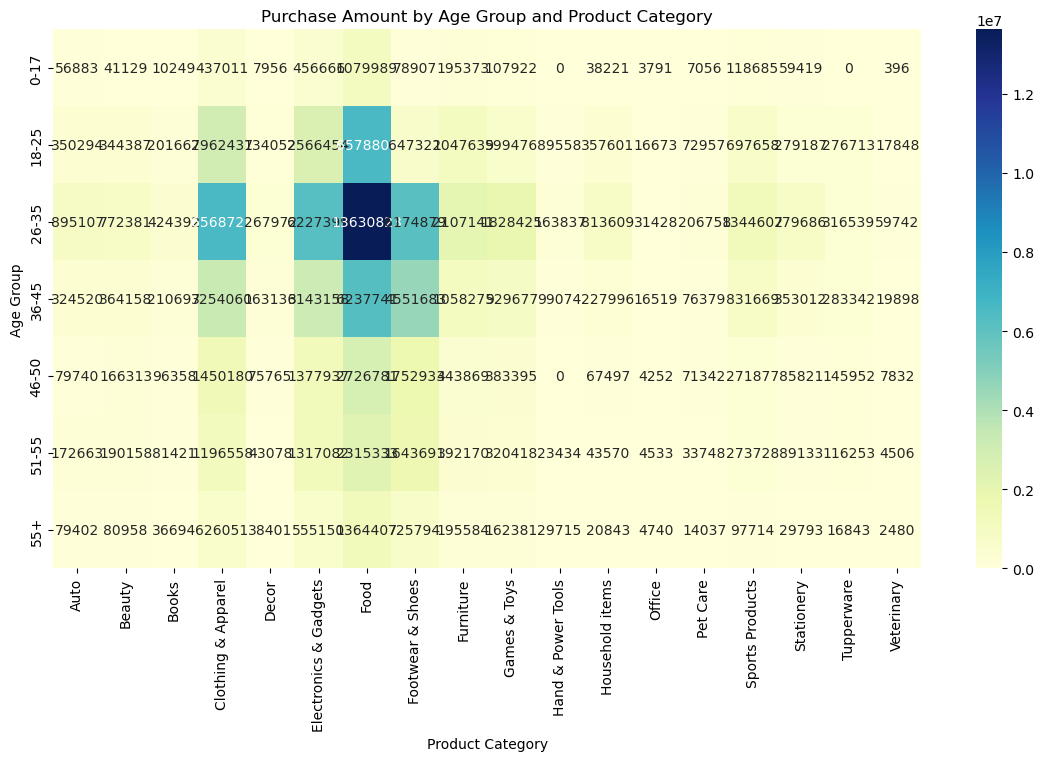

In [85]:
plt.figure(figsize=(14,7))

sns.heatmap(
    age_product,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Purchase Amount by Age Group and Product Category")

plt.xlabel("Product Category")

plt.ylabel("Age Group")

plt.show()

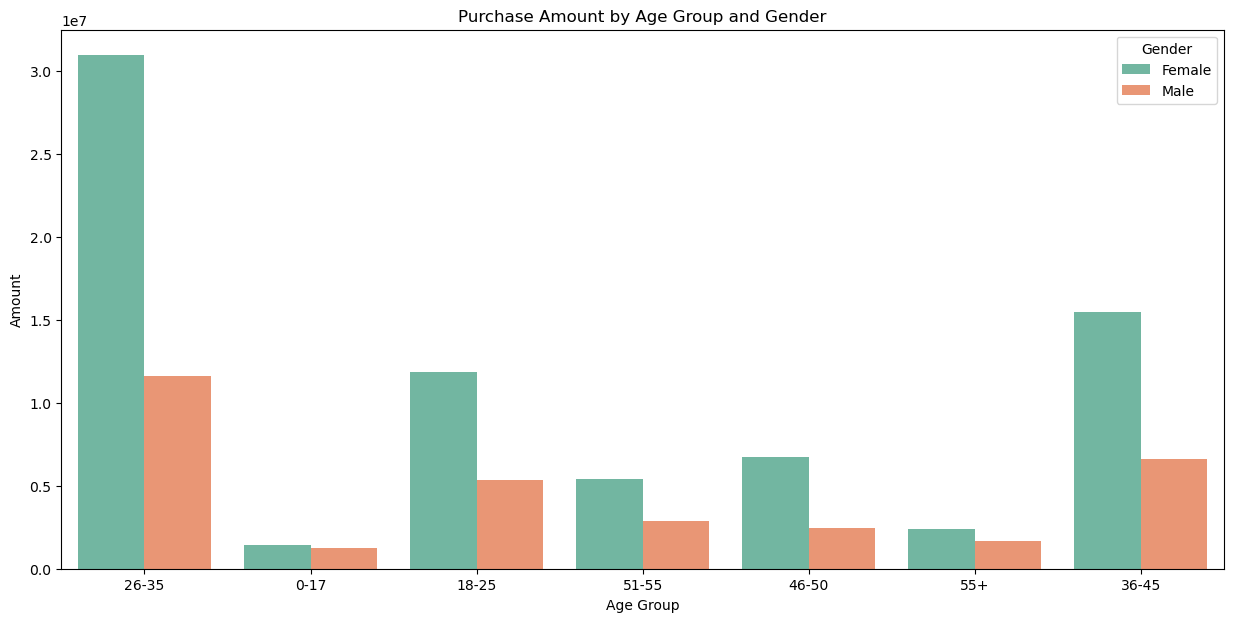

In [86]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=df,
    x='Age Group',
    y='Amount',
    hue='Gender',
    estimator=sum,
    errorbar=None,
    palette='Set2'
)

plt.title("Purchase Amount by Age Group and Gender")

plt.show()

### Observation

• The 26–35 age group contributes the highest sales across multiple product categories.
• Female customers generally spend more than male customers within most age groups.
• Certain product categories receive higher spending from specific age segments.

## 2. How does the amount spent vary by marital status across different age groups?

### Business Question

How does customer spending vary based on marital status across different age groups?

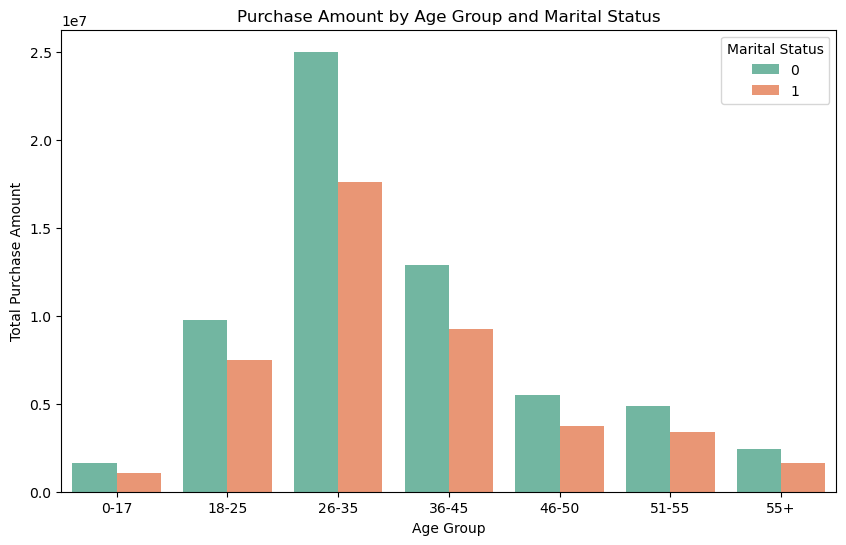

In [77]:
marital_age = (
    df.groupby(['Age Group', 'Marital_Status'])['Amount']
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=marital_age,
    x='Age Group',
    y='Amount',
    hue='Marital_Status',
    palette='Set2',
    errorbar=None
)

plt.title('Purchase Amount by Age Group and Marital Status')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount')
plt.legend(title='Marital Status')

plt.show()

### Observation

- Spending patterns differ across age groups and marital status.
- Married customers generally contribute higher purchase amounts.
- The highest spending is observed among customers aged 26–35 years.

## 3. Which states show the highest growth in orders and revenue, and are there seasonal spikes in sales?

### Business Question

Which states generate the highest orders and revenue, and can seasonal sales trends be identified?

In [78]:
state_summary = (
    df.groupby('State')
      .agg(
          Total_Orders=('Orders', 'sum'),
          Total_Revenue=('Amount', 'sum')
      )
      .sort_values(by='Total_Revenue', ascending=False)
)

state_summary

,Total_Orders,Total_Revenue
State,,
Uttar Pradesh,4807,19374968
Maharashtra,3810,14427543
Karnataka,3240,13523540
Delhi,2740,11603818
Madhya Pradesh,2252,8101142
Andhra Pradesh,2051,8037146
Himachal Pradesh,1568,4963368
Haryana,1109,4220175
Bihar,1062,4022757


### Observation

The dataset does not contain any transaction date or time information. Therefore:

- States with the highest total orders and revenue can be identified.
- Seasonal trends, monthly growth, and sales spikes cannot be analyzed using the available data.

Additional date-related information would be required to perform time-series or seasonal analysis.

## 4. Are there specific occupations that prefer particular product categories more than others?

### Business Question

Do customers from different occupations exhibit preferences for specific product categories?

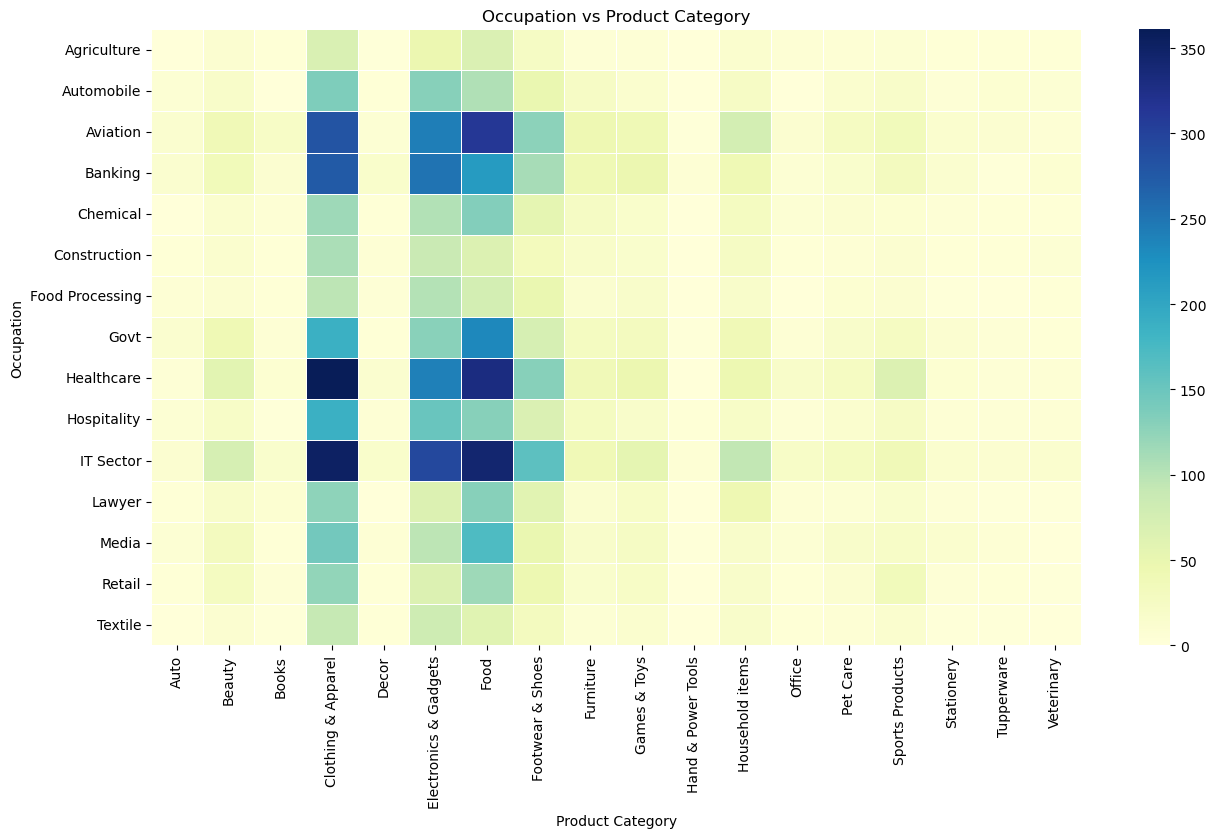

In [79]:
occupation_product = (
    df.groupby(['Occupation', 'Product_Category'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(15,8))

sns.heatmap(
    occupation_product,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Occupation vs Product Category')

plt.xlabel('Product Category')

plt.ylabel('Occupation')

plt.show()

### Observation

- Different occupations display varying purchasing preferences across product categories.
- Certain occupations contribute more heavily to specific product categories than others.
- This indicates that occupation influences product purchasing behavior.

## 5. What is the correlation between age and spending amount, and does this differ by gender?

### Business Question

Is there a relationship between customer age and spending amount, and does this relationship vary by gender?

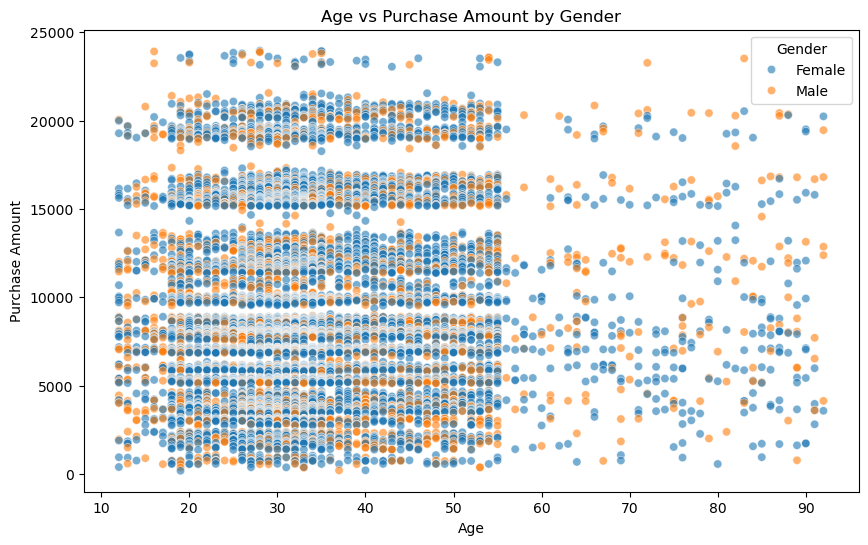

In [81]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Amount',
    hue='Gender',
    alpha=0.6
)

plt.title('Age vs Purchase Amount by Gender')

plt.xlabel('Age')

plt.ylabel('Purchase Amount')

plt.show()

In [82]:
correlation = df[['Age', 'Amount']].corr()

correlation

,Age,Amount
Age,1.000000,0.030941
Amount,0.030941,1.000000


### Observation

- The scatter plot illustrates the relationship between customer age and purchase amount.
- The correlation coefficient indicates whether age has a strong, weak, or negligible relationship with spending.
- Spending patterns may differ slightly between male and female customers.